In [14]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
insurance_data = pd.read_csv("insurance.csv")

X= insurance_data.drop(columns = ["charges"])
Y = insurance_data["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=False)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"]*X["smoker"]
X["bmi_smoker"] = X["bmi"]*X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)



In [9]:

alpha = [0.001,0.1,1,2,10,40,50,100]
mses = []
for a in alpha:
    lasso_model = Lasso(a)
    lasso_model.fit(X_train,y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    print("MSE : ",mse)
    mses.append(mse)

MSE :  20922596.528006196
MSE :  20921899.287567727
MSE :  20915761.347724434
MSE :  20909904.882848244
MSE :  20879460.42907431
MSE :  21030365.00375737
MSE :  21137371.39625106
MSE :  22325946.521791276


<Axes: >

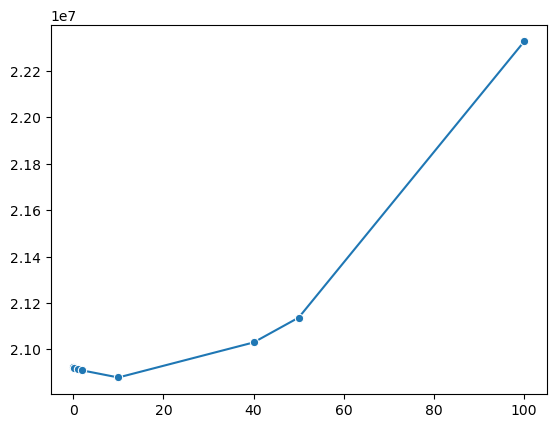

In [10]:
sns.lineplot(x=alpha,y=mses,marker="o")

In [17]:
from sklearn.linear_model import LassoCV
a = [0.001,0.0001,0.1,1,2,10,40,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)
lasso_cv_model.fit(X_train,y_train)

print("best alpha",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
print("mse ",mse)
r2 = r2_score(y_test,y_pred)
r2

best alpha 0.0001
mse  20922606.796719372


0.8652317053049284